In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("..")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tick.hawkes import SimuHawkesExpKernels, SimuHawkesSumExpKernels

from src.model import (
    DHP,
    CHP, CHP_plot, CHP_IC, CHP_IC_plot,
    neg_log_likelihood, hawkes_residuals,
    neg_log_likelihood_bivariate, hawkes_residuals_bivariate,
    spectral_det, trace_1, trace_2,
    engle_russell_ed_test, _default_bivariate_bounds,
    fit_univariate, univariate_goodness_of_fit, pass_rate_univariate,
    simulate_bivariate, fit_bivariate, bivariate_goodness_of_fit,
    pass_rate_bivariate_sim,fit_bivariate_sum_exp,neg_log_likelihood_bivariate_sum_exp,
    hawkes_residuals_bivariate_sum_exp,bivariate_goodness_of_fit_sum_exp,_eval_window_sum_exp,
    qq_overlay,_sample_random_windows,_aggregate_pass_rates, _print_pass_rate_summary, pass_rate_by_window_size_bivariate, pass_rate_by_window_size_sum_exp,
    compare_kernels_by_window_size
)

from src.data import (
    build_hawkes_dataframe,
    extract_time_window,
    initialize_hawkes_params,
    initialize_hawkes_params_sum_exp,
)

In [4]:
from scipy.optimize import brentq
from scipy.optimize import minimize, NonlinearConstraint,LinearConstraint
from scipy.stats import norm
from scipy import stats


from scipy.stats import kstest, expon
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from tick.hawkes import SimuHawkesExpKernels

In [5]:
import nest_asyncio
from tardis_dev import download_datasets_async
import glob, pandas as pd

nest_asyncio.apply()

await download_datasets_async(
    exchange="binance",
    data_types=["trades"],
    from_date="2026-09-01",
    to_date="2026-09-02",
    symbols=["BTCUSDT"],
    download_dir="../data",
)


files = glob.glob("../data/*.csv.gz")
print("Fichiers téléchargés :", files)

df = pd.read_csv(files[0])

Fichiers téléchargés : ['../data/binance_trades_2026-09-01_BTCUSDT.csv.gz']


In [6]:
%matplotlib inline

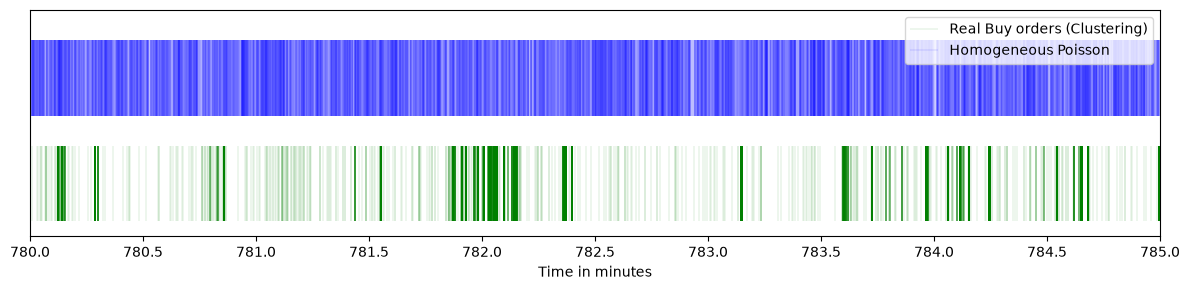

In [7]:
df_bar = df.copy()

minute_start = 780.0
minute_end = 785.0


# temporal normalisation
df_bar["timestamp"] = df_bar["timestamp"] - df_bar["timestamp"].iloc[0]

# Conversion in minutes
df_bar["timestamp_minutes"] = df_bar["timestamp"] / 6e7

# Filter
mask_buy = (df_bar["side"] == 'buy') & (df_bar["timestamp_minutes"] >= minute_start) & (df_bar["timestamp_minutes"] <= minute_end)

buy_zoom = df_bar.loc[mask_buy, "timestamp_minutes"].to_numpy()



T_max = minute_end - minute_start  # Here, 5.0 minutes
lambda_poisson = len(buy_zoom) / T_max

N_poisson = np.random.poisson(lambda_poisson * T_max)

poisson_events = np.sort(np.random.uniform(0, T_max, N_poisson))

# Shift to align simulated events with the actual observation window
poisson_events += minute_start

# Comparative visualization
fig, ax = plt.subplots(figsize=(12, 3)) 
ax.set_ylim(0, 1.5) # Extended limit to stack the timelines
ax.set_xlim(minute_start, minute_end)
ax.set_xticks(np.arange(minute_start, minute_end + 0.1, 0.5))

# Display actual data (empirical Hawkes) at the bottom
ax.vlines(x=buy_zoom, ymin=0.1, ymax=0.6, color='green', linewidth=0.1, alpha=1, label='Real Buy orders (Clustering)')

# Display Poisson process (memoryless) at the top
ax.vlines(x=poisson_events, ymin=0.8, ymax=1.3, color='blue', linewidth=0.1, alpha=1, label='Homogeneous Poisson')

ax.get_yaxis().set_visible(False)
ax.set_xlabel('Time in minutes')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [8]:
df_bar['timestamp'] = pd.to_datetime(df_bar['timestamp'], unit='us')
df_bar.set_index('timestamp', inplace=True)

df_bar['buy'] = (df_bar['side'] == 'buy').astype(int)
df_bar['sell'] = (df_bar['side'] == 'sell').astype(int)


df_buy_binned = df_bar['buy'].resample('1min').sum()
df_sell_binned = df_bar['sell'].resample('1min').sum()

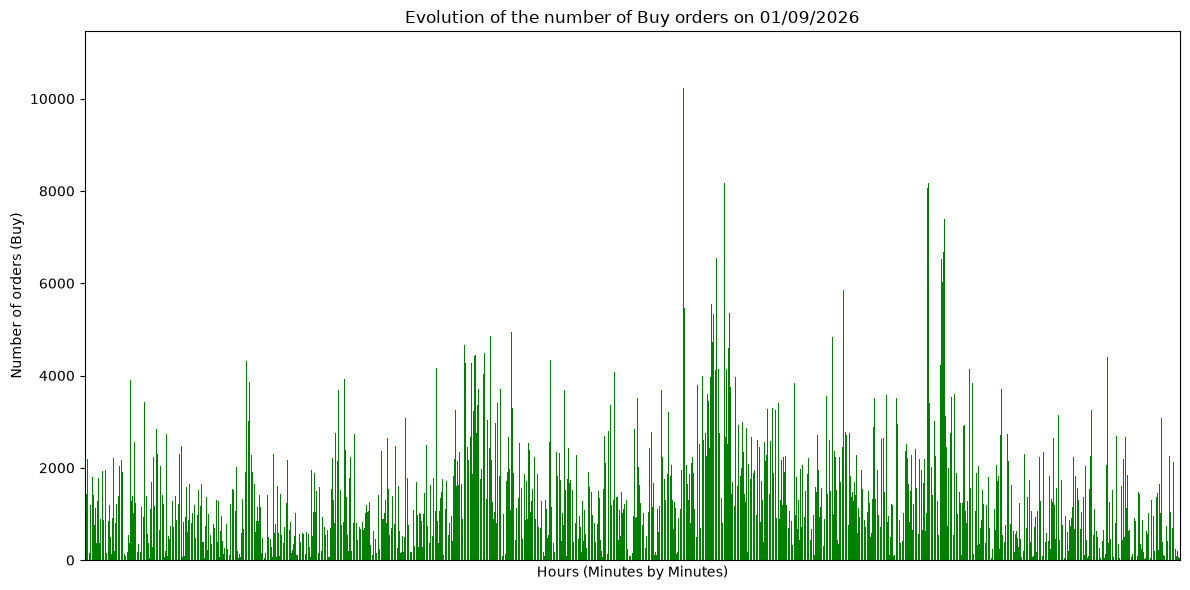

In [9]:
df_buy_binned.plot(kind='bar', figsize=(12, 6), color='green', width=0.8)

plt.xticks([])
plt.xlabel("Hours (Minutes by Minutes)")
plt.ylabel("Number of orders (Buy)")
plt.title("Evolution of the number of Buy orders on 01/09/2026")
plt.tight_layout()
plt.show()

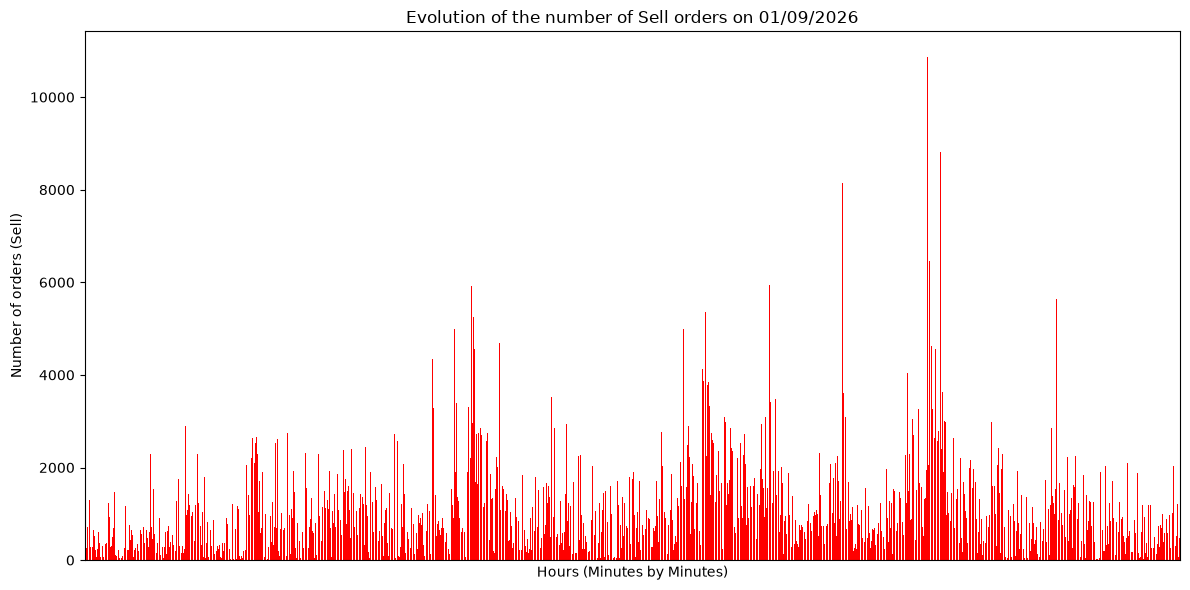

In [10]:
df_sell_binned.plot(kind='bar', figsize=(12, 6), color='red', width=0.8)

plt.xticks([])
plt.xlabel("Hours (Minutes by Minutes)")
plt.ylabel("Number of orders (Sell)")
plt.title("Evolution of the number of Sell orders on 01/09/2026")
plt.tight_layout()
plt.show()

In [11]:
# Make the DataFrame workable for Hawkes processes

df_total_hawkes = build_hawkes_dataframe(df) 

# Extract a window of 5 mins at 1:00pm

df_hawkes = extract_time_window(df_total_hawkes['time_stamp'], df_total_hawkes['side'], start=13*3600, duration=5*60)

# Initialization of Hawkes Parameters : empirical way using the window

theta_init, bounds, constraints = initialize_hawkes_params(df_hawkes['time_stamp'], df_hawkes['side'])

In [12]:
# Fit of a bivariate Hawkes on the BTC/USDT using exp kernel

resultat = fit_bivariate(df_hawkes,
                  theta_init=theta_init,
                  method='trust-constr',
                  bounds=bounds,
                  constraints=None,
                  verbose=False)


theta_estimate=resultat.x

/opt/python/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)


In [13]:
print(theta_estimate)

[2.07205428e+00 1.73060981e+00 4.14426663e-01 1.70423775e-03
 2.43826813e-03 5.89282664e-01 3.54388077e+02 1.25440390e+02]


In [14]:
# Bivariate goodness of fit (for exp_kernel) : u1,u2 are the residuals we test

(u1, u2), results = bivariate_goodness_of_fit(theta_estimate, df_hawkes, verbose=True)

--- Goodness of fit (bivarie) ---
KS: 0.0843 (p=0.0000) | LB: 573.1163 (p=0.0000) | ED: 3.2692 (p=0.0011) | var=1.2836
KS: 0.0588 (p=0.0003) | LB: 198.4199 (p=0.0000) | ED: 4.1963 (p=0.0000) | var=1.3336


In [15]:
# Initialization of Hawkes parameters for sum of exp kernel 
# We do not need bounds and constraints, because they will be automatically chosen by during the fit : we only use trust-constr.

theta_init_sum = initialize_hawkes_params_sum_exp(df_hawkes['time_stamp'], df_hawkes['side'])

In [16]:
# Fit of a bivariate Hawkes on the BTC/USDT using sum exp kernel

resultat_sum  = fit_bivariate_sum_exp(df_hawkes,
                          theta_init_sum,
                          verbose=False)


theta_estimate_sum=resultat_sum.x

/opt/python/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/opt/python/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:385: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


In [17]:
# Bivariate goodness of fit (for sum exp kernel) : u1,u2 are the residuals we test

(v1,v2), results = bivariate_goodness_of_fit_sum_exp(theta_estimate_sum, df_hawkes, verbose=True)

--- Goodness of fit (sum-exp) ---
KS: 0.0384 (p=0.0853) | LB: 316.2119 (p=0.0000) | ED: -0.6016 (p=0.5475) | var=0.9478
KS: 0.0361 (p=0.0720) | LB: 109.1768 (p=0.0000) | ED: 1.3531 (p=0.1760) | var=1.1076


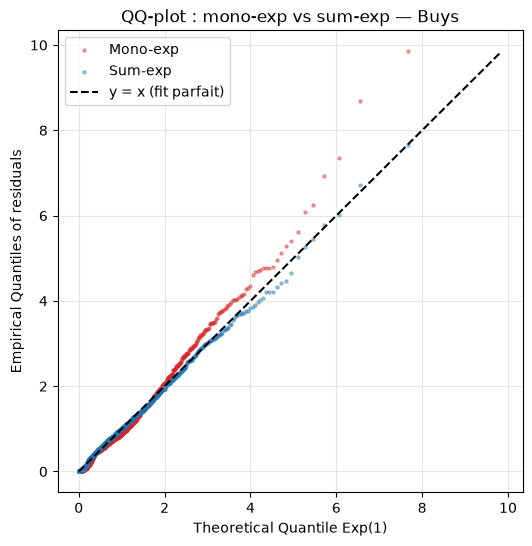

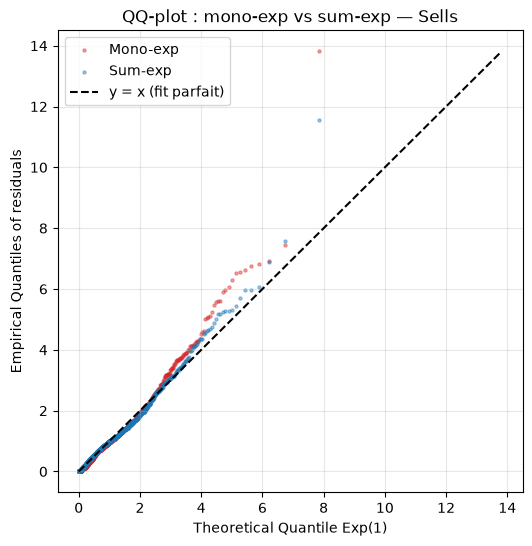

In [18]:
%matplotlib inline

# QQ-plot for Dimension Buys
qq_overlay(u1, v1, "Buys")

# QQ-plot for Dimension Sells
qq_overlay(u2, v2, "Sells")

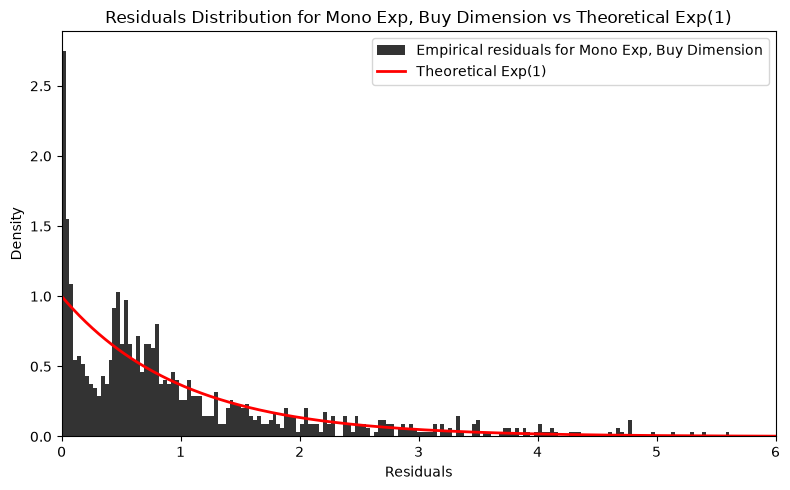

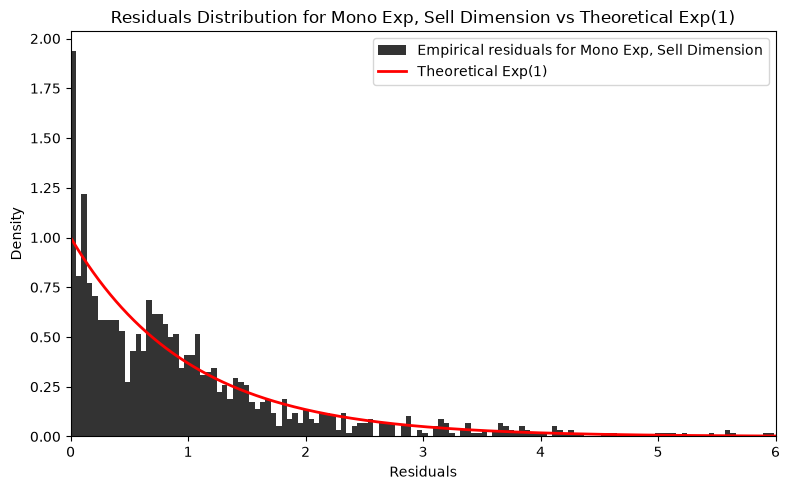

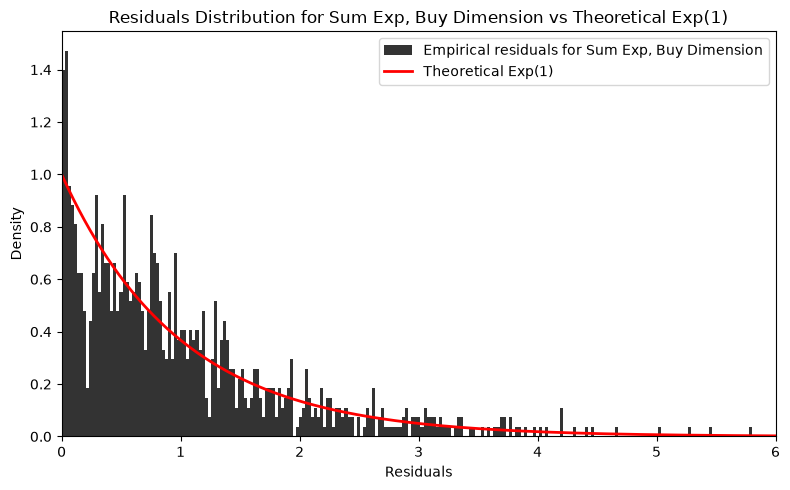

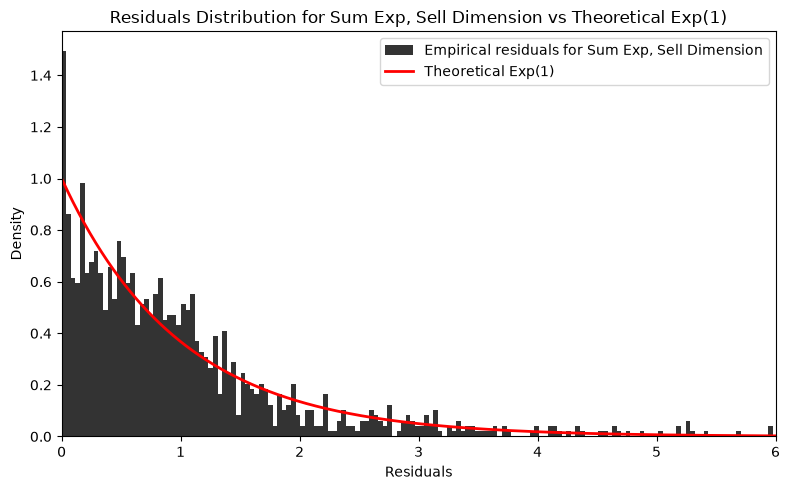

In [19]:
residuals=[u1,u2,v1,v2]

for r in residuals :
    r.sort()

names = [
    "Mono Exp, Buy Dimension",
    "Mono Exp, Sell Dimension",
    "Sum Exp, Buy Dimension",
    "Sum Exp, Sell Dimension"
]

for r, name in zip(residuals, names):

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(
        r,
        bins=300,
        density=True,
        alpha=0.8,
        color='black',
        label=f'Empirical residuals for {name}'
    )

    x_grid = np.linspace(0, 6, 1000)
    pdf_exp = np.exp(-x_grid)

    ax.plot(
        x_grid,
        pdf_exp,
        color='red',
        lw=2,
        label='Theoretical Exp(1)'
    )

    ax.set_xlim(0, 6)
    ax.set_xlabel('Residuals')
    ax.set_ylabel('Density')
    ax.set_title(f'Residuals Distribution for {name} vs Theoretical Exp(1)')
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


